In [65]:
from pathlib import Path

import cv2
import numpy as np
from IPython.display import display
from PIL import Image

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Affine augmentation with padding/crop

In [59]:
IMAGE_PATHS = {
    "infrared": REPO_ROOT / "data_sources/lasher/testingset/boywalkinginsnow2/infrared/000000.jpg",
    "visible": REPO_ROOT / "data_sources/lasher/testingset/boywalkinginsnow2/visible/000000.jpg",
}

infra_img = cv2.imread(str(IMAGE_PATHS["infrared"]), cv2.IMREAD_COLOR)
visible_img = cv2.imread(str(IMAGE_PATHS["visible"]), cv2.IMREAD_COLOR)

if infra_img is None or visible_img is None:
    missing = [name for name, img in (("infrared", infra_img), ("visible", visible_img)) if img is None]
    raise FileNotFoundError(f"Could not load image(s): {missing}")


In [60]:
def resize_to_canvas(img, canvas_h=960, canvas_w=1280):
    return cv2.resize(img, (canvas_w, canvas_h), interpolation=cv2.INTER_AREA)


def center_crop(img, crop_h=480, crop_w=640):
    h, w = img.shape[:2]
    if crop_h > h or crop_w > w:
        raise ValueError(f"Crop {(crop_h, crop_w)} is larger than image {(h, w)}")

    y1 = (h - crop_h) // 2
    x1 = (w - crop_w) // 2
    return img[y1:y1 + crop_h, x1:x1 + crop_w]


def affine_transform(img, dx=0, dy=0, angle_deg=0.0):
    h, w = img.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle_deg, 1.0)
    matrix[0, 2] += dx
    matrix[1, 2] += dy

    transformed = cv2.warpAffine(
        img,
        matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    return transformed, matrix


def display_cv2_image(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(img))


In [61]:
def generate_ir_misaligned_sample(
    visible_img,
    ir_img,
    target_h=480,
    target_w=640,
    canvas_h=960,
    canvas_w=1280,
    max_dx=100,
    max_dy=100,
    max_angle=20,
    rng=None,
):
    rng = np.random.default_rng() if rng is None else rng

    visible_large = resize_to_canvas(visible_img, canvas_h, canvas_w)
    ir_large = resize_to_canvas(ir_img, canvas_h, canvas_w)

    dx = int(rng.integers(-max_dx, max_dx + 1))
    dy = int(rng.integers(-max_dy, max_dy + 1))
    angle = float(rng.uniform(-max_angle, max_angle))

    ir_transformed, matrix = affine_transform(ir_large, dx=dx, dy=dy, angle_deg=angle)
    label = np.array([dx, dy, angle], dtype=np.float32)

    return {
        "visible": center_crop(visible_large, target_h, target_w),
        "infrared": center_crop(ir_transformed, target_h, target_w),
        "label": label,
        "matrix": matrix,
    }


label: [70.       28.       -9.208531]
visible: (480, 640, 3)
infrared: (480, 640, 3)


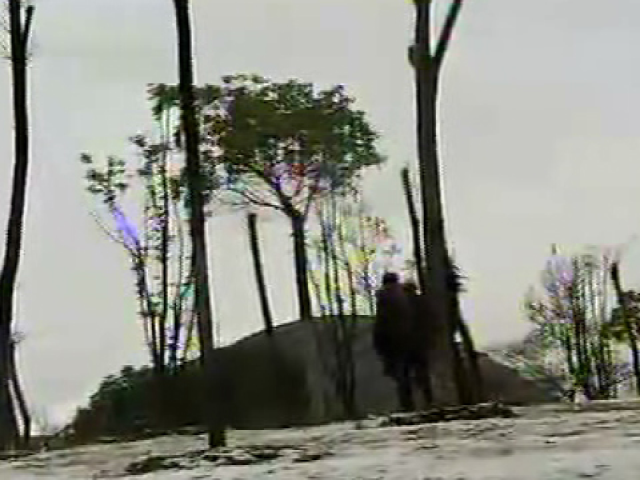

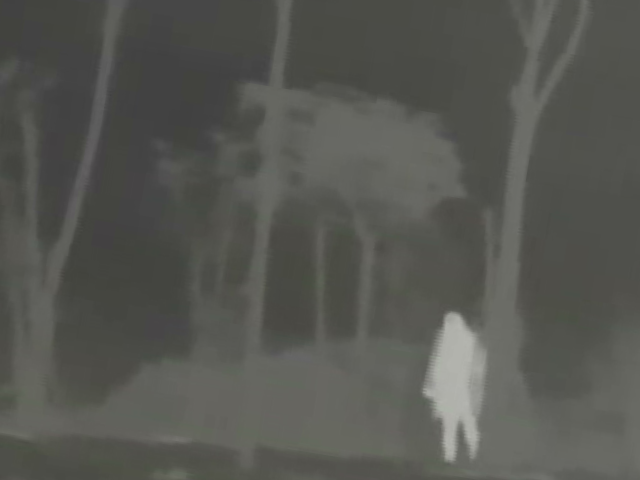

In [62]:
sample = generate_ir_misaligned_sample(visible_img, infra_img, rng=np.random.default_rng(0))

print("label:", sample["label"])
print("visible:", sample["visible"].shape)
print("infrared:", sample["infrared"].shape)

display_cv2_image(sample["visible"])
display_cv2_image(sample["infrared"])


label: [-50.  20.   0.]


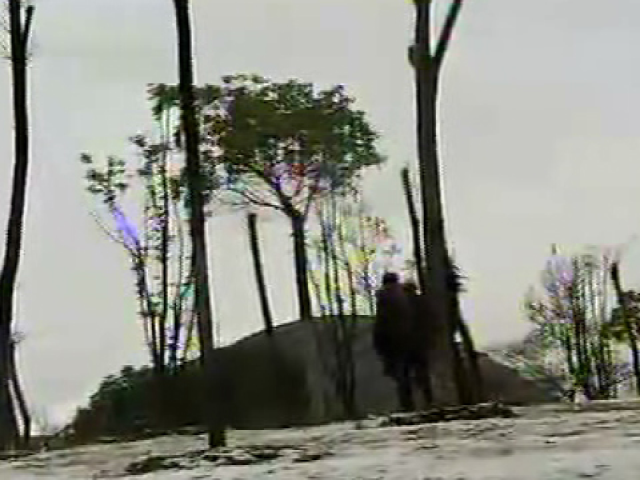

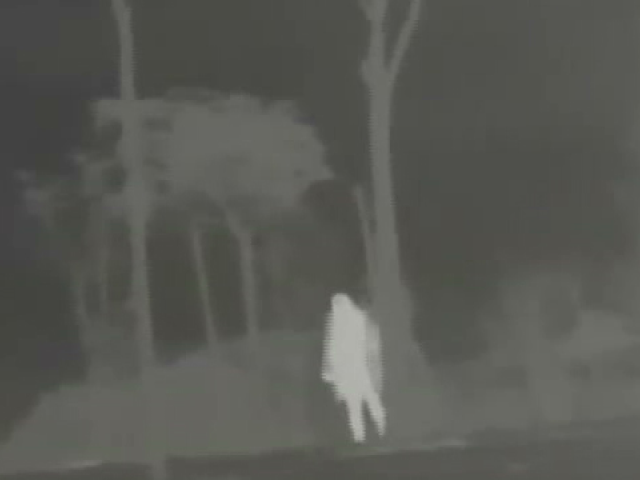

In [63]:
dx, dy, angle = -50, 20, 0.0

visible_large = resize_to_canvas(visible_img)
ir_large = resize_to_canvas(infra_img)
ir_transformed, matrix = affine_transform(ir_large, dx=dx, dy=dy, angle_deg=angle)

fixed_sample = {
    "visible": center_crop(visible_large),
    "infrared": center_crop(ir_transformed),
    "label": np.array([dx, dy, angle], dtype=np.float32),
    "matrix": matrix,
}

print("label:", fixed_sample["label"])
display_cv2_image(fixed_sample["visible"])
display_cv2_image(fixed_sample["infrared"])
